<a href="https://colab.research.google.com/github/johnryantaylor/QCES/blob/main/Project3_tsunami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Tsunami
In this project, we will use Dedalus to model the propagation of Tsunami waves. Tsunami typically have wavelengths larger than 100km and periods of about 1 hour. Since their wavelength is much larger than the depth of the ocean, Tsunami can be modelled using the shallow water equations.

Here, we will use Dedalus to solve an initial value problem for the shallow water equations. We will generate a Tsunami using a localized disturbance to the water height.

Student tasks are in [Section 1.3]( #section1pt3 ), [Section 2.3]( #section2pt3 ), and [Section 3.3]( #section3pt3 ).

## Setup
If you are using Google colab, run the script below to install Dedalus

In [18]:
# Set environment variables for best performance
%env OMP_NUM_THREADS=1
%env NUMEXPR_MAX_THREADS=1

# Minimize logging output
import logging
logging.disable(logging.DEBUG)

# Check if running on google colab
import os
using_google_colab = bool(os.getenv("COLAB_RELEASE_TAG"))

# Check for Dedalus
try:
    import dedalus.public as de
    print("Dedalus already installed :)")
except:
    print("Dedalus not installed yet.")
    if using_google_colab:
        print("Installing for Google Colab.")
        print()
        # Step 1: Install FFTW
        !apt-get install libfftw3-dev
        !apt-get install libfftw3-mpi-dev
        # Step 2: Set paths for Dedalus installation
        import os
        os.environ['MPI_INCLUDE_PATH'] = "/usr/lib/x86_64-linux-gnu/openmpi/include"
        os.environ['MPI_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        os.environ['FFTW_INCLUDE_PATH'] = "/usr/include"
        os.environ['FFTW_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        # Step 3: Install Dedalus using pip
        !pip3 install cython "mpi4py<4.0" numpy setuptools wheel
        !CC=mpicc pip3 install --no-cache --no-build-isolation http://github.com/dedalusproject/dedalus/zipball/master/
        !pip3 install -q ipympl
        # Step 4: Check installation
        print()
        try:
            import dedalus.public as de
            print("Dedalus successfully installed :)")
        except:
            print("Error installing Dedalus :(")
            raise
    else:
        print("See website for installation instructions:")
        print("https://dedalus-project.readthedocs.io/en/latest/pages/installation.html")

# Setup interactive matplotlib
if using_google_colab:
    from google.colab import output
    output.enable_custom_widget_manager()

env: OMP_NUM_THREADS=1
env: NUMEXPR_MAX_THREADS=1
Dedalus already installed :)


## 1.  1D shallow water equations
Let's start by solving the shallow water equations in 1D with periodic boundary conditions in our spatial variable, $x$. The script below solves the following equations:

$$ \partial_t u + g \partial_x(h) = - u\partial_x u$$
$$ \partial_t h + \partial_x(Hu) = -\partial_x(hu)$$

In these equations, $g$ is the constant gravitational acceleration, $u$ is the velocity in the $x$ direction, $H$ is the resting height, and $h$ is the height of the free surface relative to $H$. Note that the terms on the right hand side are nonlinear in our dependent variables, and we will use an explicit timestepping method for these terms. Recall that Dedalus uses explicit timestepping for terms on the right hand side of the inputted equation.

Because we are interested in an application to Tsunami, we will solve the equations using dimensional variables. It is convenient to define simulation units at the start of the script so that we can be explicit about the units.

We will start with the following initial conditions:
$$ h=e^{-(x-x_1)^2/w_1^2} $$
$$ u=(c/g)h $$
where $x_1$ is the center and $w_1=100$ km is the width of the Gaussian perturbation. This generates a wave that will propagate to the right with speed $c$ before it encounters the seamount.

To see how the waves change as they approach shallow water, we will set the resting water depth to include a localized seamount using the form:
$$ H=H_0-(H_0-H_{min})e^{(-(x-x_2)^2/w_2^2)} $$
where $x_2$ is the location of the seamount, $H_0=4$ km is the depth of the ocean away from the seamount, and $H_{min}$ is the minimum water depth above the seamount. Note that since $H\ll w$, the shallow water approximation is appropriate here.

### 1.1  Dedalus script to solve the 1D shallow water equations

The script below solves the 1D shallow water equations with the initial conditions given above.

In [19]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size
Nx = 512 # The number of gridpoints in x
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
w1 = 20 * kilometer # Width of the initial perturbation
x1 = 200 * kilometer # Center of the initial perturbation
x2 = 500 * kilometer # Center of the seamount
w2 = 100 * kilometer # Width of the seamount
H_min = 100 * meter # minimum depth above the seamount
c = np.sqrt(g*H0) # Wave speed

timestep = 60 * second # Specify the timestep
stop_sim_time = 100 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Create an x-coordinate, a corresponding basis, and a distributor
xcoord = dedalus.Coordinate('x')
dist = dedalus.Distributor(xcoord, dtype=np.float64) # No mesh for serial / automatic parallelization
x_basis = dedalus.RealFourier(xcoord, size=Nx, bounds=(0, Lx))
x = dist.local_grid(x_basis)

# Specify the Fields and set the initial conditions
u = dist.Field(name='u', bases=x_basis)
h = dist.Field(name='h', bases=x_basis)
H = dist.Field(name='H', bases=x_basis)
h.change_scales(1)
H.change_scales(1)
u.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-(x-x2)**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2.0/w1**2.0)  # Initialize the height with a Gaussian function with width set above
u['g'] = (g/c)*h['g']

# Operators
dx = lambda a: dedalus.Differentiate(a, xcoord)

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u)")
problem.add_equation("dt(h) + dx(H*u) = - dx(h*u)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.1e+01/s


2025-11-25 23:17:18,114 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.1e+01/s


INFO:__main__:Starting main loop


2025-11-25 23:17:18,120 __main__ 0/1 INFO :: Starting main loop


INFO:solvers:Simulation stop time reached.


...

2025-11-25 23:17:18,313 solvers 0/1 INFO :: Run time (iter 10-end): 0.1427 sec


INFO:solvers:CPU time (iter 10-end): 3.963e-05 cpu-hr


2025-11-25 23:17:18,316 solvers 0/1 INFO :: CPU time (iter 10-end): 3.963e-05 cpu-hr


INFO:solvers:Speed: 1.29e+06 mode-stages/cpu-sec


2025-11-25 23:17:18,317 solvers 0/1 INFO :: Speed: 1.29e+06 mode-stages/cpu-sec


### 1.2  Plotting
The code below will make a movie of the height.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-25 23:17:22,754 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp4ne3yc71/temp.m4v


2025-11-25 23:17:22,755 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp4ne3yc71/temp.m4v


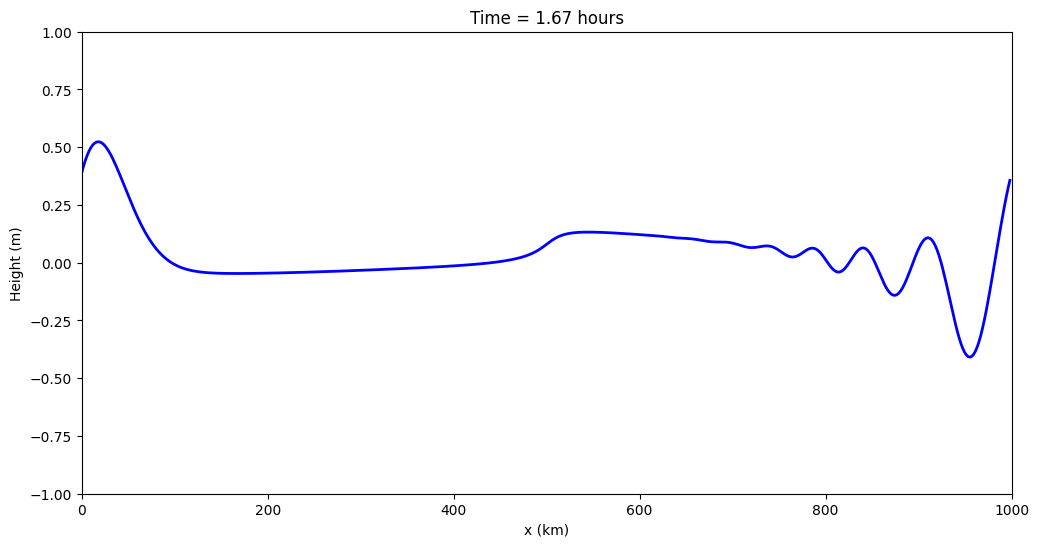

In [20]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Specify the axis limits and labels
plt.xlim((0, Lx / (1*kilometer)))
plt.ylim((-1, 1))
plt.xlabel('x (km)')
plt.ylabel('Height (m)')

# Create objects that will change during the animation
txt_title = plt.title('')
height, = plt.plot([], [], 'b', lw=2)

# Define an animation function
def drawframe(n):
    height.set_data(x/(1*kilometer), h_save[n,:])
    txt_title.set_text('Time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())


### 1.3 Student investigation
<a id='section1pt3'></a>
In the cells below, provide an expression for the expected wave speed and state any assumptions that are necessary to arrive at this. Then plot the wave speed from the output above and compare this with the expected value.

To Linearise the shallow water equations we essentially take the time derivative of (1) and the spatial derivative of (2). We then elimate dh/dxdt this allows us to elimnate all the terms that inlcude dh/dx and it's further derivatives. This is because we know L_w << L_b essenially the length scale of the sea mount is much less than that of the surafce displacement. So dh / dx ~ H_0 - Hmin / L_b and du/dx ~ U / L_w. so we can consider only the d^2u /dx^2. We then get a wave equation and assume solutions in the form. U = u_0* cos(k(x - ct)) we plug this into our equation and then get a wake speed of c = sqrt(gH(x))

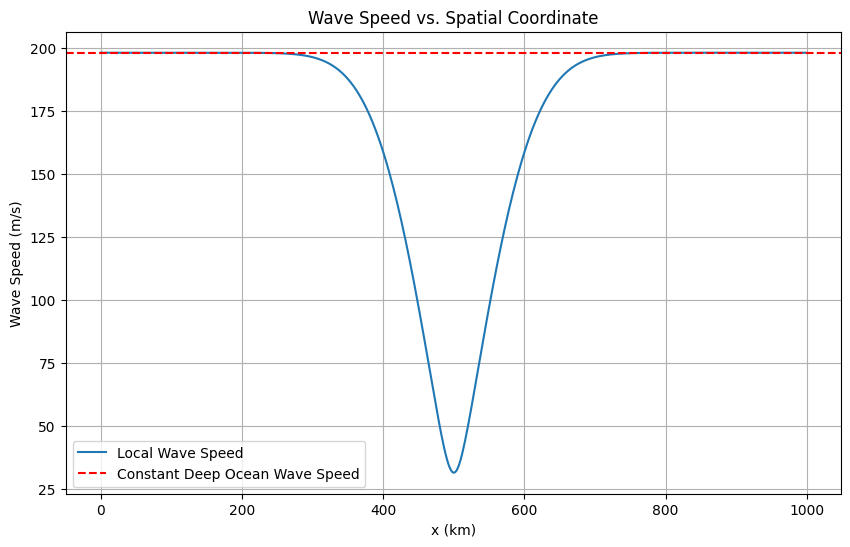

In [21]:
# Calculate the local wave speed using the varying ocean depth
c_varied = np.sqrt(g * H['g'])

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x / kilometer, c_varied, label='Local Wave Speed')
plt.axhline(y=c, color='r', linestyle='--', label='Constant Deep Ocean Wave Speed') # Plot constant c

# Add labels, title, and legend
plt.xlabel('x (km)')
plt.ylabel('Wave Speed (m/s)')
plt.title('Wave Speed vs. Spatial Coordinate')
plt.legend()
plt.grid(True)
plt.show()

From our two eqautions, the line up really well away from the sea mount, but as they get close to it we see the value that relies on x start slow down due to it's interaction with the sea mount.

## 2.  2D Shallow water equations

Now, let's see how things change if we move to two dimensions. The script below solves the 2D shallow water equations:

$$ \partial_t u + g \partial_x(h) = - u*\partial_x u - v*\partial_y u$$
$$ \partial_t u + g \partial_y(h) = - u*\partial_x v - v*\partial_y v$$
$$ \partial_t h + \partial_x(u*H) + \partial_y(v*H)) = -\partial_x(h*u) - \partial_y(h*v)$$

We will initilize the Tsunami with the following equation
$$ h=e^{-x^2/w_1^2} $$
$$ u=(g/c)*h $$

where $c=\sqrt{gH_0}$ and $H_0$ is the constant reference depth. The relationship between $u$ and $h$ follows from linearized shallow water equations and corresponds to a wave propagating in the $+x$ direction with a speed $c$.

We will solve the equations in a square domain with periodic boundary conditions and a Gaussian seamount in the middle of the domain with total undisturbed fluid height

$$ H=H_0 - (H_0 - H_{min})e^{-(x^2+y^2)/w_2^2} $$

The Tsunami should propagate with speed $c$ over the deep ocean where the depth is constant, but the wave will be modified as it passes over the seamount.

### 2.1  Dedalus script to solve the 2D shallow water equations

INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 17s, Remaining: 0s, Rate: 6.0e-02/s


2025-11-25 23:18:02,962 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 17s, Remaining: 0s, Rate: 6.0e-02/s


INFO:__main__:Starting main loop


2025-11-25 23:18:02,969 __main__ 0/1 INFO :: Starting main loop


INFO:solvers:Simulation stop time reached.


...

2025-11-25 23:18:11,712 solvers 0/1 INFO :: Speed: 3.092e+05 mode-stages/cpu-sec


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-25 23:18:11,774 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp781f8dt0/temp.m4v


2025-11-25 23:18:11,775 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp781f8dt0/temp.m4v


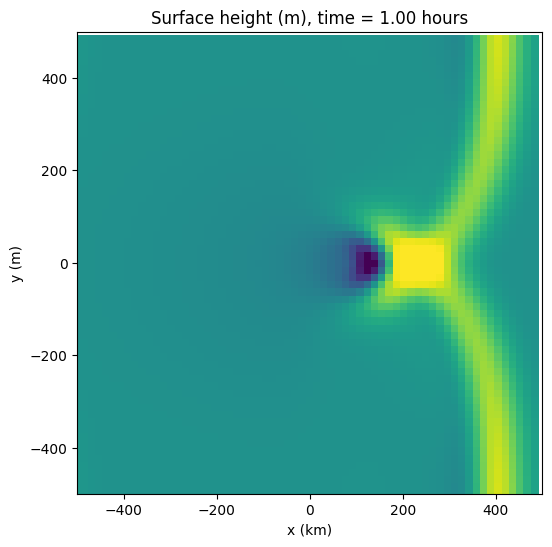

In [22]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 1 * kilometer # minimum depth above the seamount
w1 = 50 * kilometer # Set the width of the wave
w2 = 200 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 60 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing


# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

### 2.2  Plotting
The code below will make a movie of the height as a function of x and y

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-25 23:19:46,269 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpd0hj16db/temp.m4v


2025-11-25 23:19:46,271 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpd0hj16db/temp.m4v


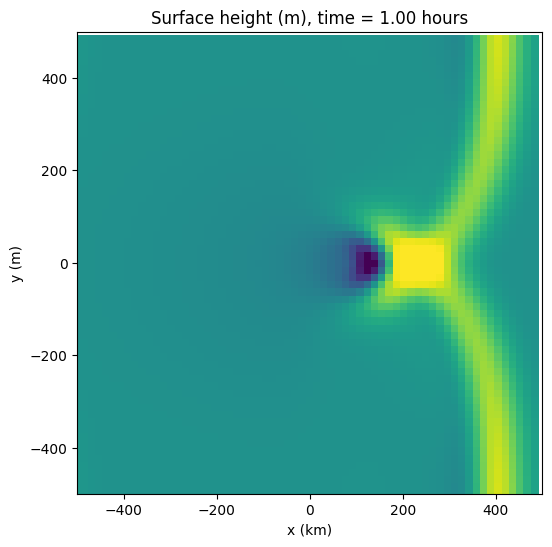

In [23]:
# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

### 2.3 Student investigation
<a id='section2pt3'></a>
Qualitatively describe the influence of the seamount and explain this behavior using the shallow water equations. You can assume that the wave amplitude and velocity are small in the shallow water equations.

STUDENT ANSWER HERE (~ 1 PARAGRAPH)

We can see that as the wave progresses towards the maximum height (yellow colour) actually doesn't change at all but it leaves a depth in it's wave that starts toexpand as travels away from the centre.
We see the height also start to bend around the boundary of the sea mount as the travelling curve looks roughly Gaussian.

To include the shallow water equations,  because terms like u du/dx and v du / dy are neglible it makes rhe momentum eqautions smooth and well defined, ensuring no breaking occurs.

We also know that as H decreases c must also decrease and that's why the wave gets slower as it goes over the sea mount

Try varying some parameters (e.g. the width and height of the wave and/or seamount) and comment on the results. When does the wave no longer obey the linear shallow water equations which are valid for small waves You don't need to do a comprehensive parameter space search, but you should run several simulations with one or two parameters varied.

In [24]:
logger = logging.getLogger(__name__)
# This code block will vary the width of the wave as it flows over the sea mount

# Define the simulation units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer
Ly = 1000 * kilometer
Nx = 64
Ny = 64
g = 9.81 * meter / second**2
H0 = 4 * kilometer
c = np.sqrt(g*H0)
H_min = 1 * kilometer
w1 = [50 * kilometer, 100 * kilometer, 200 * kilometer]  # Different wave widths
w2 = 200 * kilometer
x1 = -300 * kilometer

timestep = 60 * second
stop_sim_time = 60 * minute

# Store results for each simulation
all_simulations = []

for w_i in w1:
    print(f"Running simulation with wave width: {w_i/kilometer} km")

    # Bases
    coords = dedalus.CartesianCoordinates('x', 'y')
    dist = dedalus.Distributor(coords, dtype=np.float64)
    xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
    ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

    x, y = dist.local_grids(xbasis, ybasis)

    # Fields
    u = dist.Field(name='u', bases=(xbasis, ybasis))
    v = dist.Field(name='v', bases=(xbasis, ybasis))
    h = dist.Field(name='h', bases=(xbasis, ybasis))
    H = dist.Field(name='H', bases=(xbasis, ybasis))

    # Initial conditions
    H.change_scales(1)
    h.change_scales(1)
    u.change_scales(1)
    v.change_scales(1)
    H['g'] = H0 - (H0 - H_min) * np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
    h['g'] = np.exp(-(x - x1)**2 / w_i**2)
    u['g'] = (g / c) * h['g']
    v['g'] = 0

    # Operators
    dx = lambda a: dedalus.Differentiate(a, coords['x'])
    dy = lambda a: dedalus.Differentiate(a, coords['y'])

    # Problem
    problem = dedalus.IVP([u, v, h], namespace=locals())
    problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
    problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
    problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

    # Solver
    solver = problem.build_solver(dedalus.RK222)
    solver.stop_sim_time = stop_sim_time

    # Storage for this simulation
    h_save_current = []
    t_save_current = []

    h.change_scales(1)
    h_save_current.append(np.copy(h['g']))
    t_save_current.append(solver.sim_time)

    # Main loop
    try:
        logger.info('Starting main loop')
        while solver.proceed:
            solver.step(timestep)
            if (solver.iteration - 1) % 1 == 0:
                h.change_scales(1)
                h_save_current.append(np.copy(h['g']))
                t_save_current.append(solver.sim_time)
    except:
        logger.error('Exception raised, triggering end of main loop.')
        raise
    finally:
        solver.log_stats()

    # Store results for this simulation
    all_simulations.append({
        'width_km': w_i / kilometer,
        'h_save': np.array(h_save_current),
        't_save': t_save_current,
        'x': x,
        'y': y
    })

# Create animations for each simulation
from dedalus.extras import plot_tools

for i, sim in enumerate(all_simulations):
    print(f"Creating animation for wave width {sim['width_km']} km")

    # Create a figure
    fig = plt.figure(figsize=(8, 6))

    # Create mesh for plotting
    (X, Y) = plot_tools.quad_mesh(np.squeeze(sim['x']), np.squeeze(sim['y']))

    # Define animation function for THIS specific simulation
    def drawframe(n, h_data=sim['h_save'], t_data=sim['t_save'], width=sim['width_km']):
        plt.clf()
        # FIX: Use h_data instead of global h_save, and use proper parameter names
        height = plt.pcolormesh(X/kilometer, Y/kilometer, h_data[n,:,:].T,
                               vmin=-0.5)
        plt.xlim((-Lx/2 / kilometer, Lx/2 / kilometer))
        plt.ylim((-Ly/2 / kilometer, Ly/2 / kilometer))
        plt.xlabel('x (km)')
        plt.ylabel('y (km)')
        plt.title(f'Surface Height - Wave Width: {width} km\nTime = {t_data[n]/hour:.2f} hours')
        plt.colorbar(label='Height (m)')
        return (height,)

    # Create animation
    anim = animation.FuncAnimation(fig, drawframe, frames=len(sim['t_save']),
                                  interval=100, blit=False)

    # Display animation
    from IPython.display import HTML
    display(HTML(f'<h3>Wave Width: {sim["width_km"]} km</h3>'))
    display(HTML(anim.to_html5_video()))

    plt.close()


Running simulation with wave width: 50.0 km


INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 26s, Remaining: 0s, Rate: 3.9e-02/s


2025-11-25 23:23:54,358 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 26s, Remaining: 0s, Rate: 3.9e-02/s


INFO:__main__:Starting main loop


2025-11-25 23:23:54,360 __main__ 0/1 INFO :: Starting main loop


...

Creating animation for wave width 200.0 km


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-25 23:25:16,852 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x600 -pix_fmt rgba -framerate 10.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpih_5fd4w/temp.m4v


2025-11-25 23:25:16,855 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x600 -pix_fmt rgba -framerate 10.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpih_5fd4w/temp.m4v


For very high widths we start to see waves breaking and having these, 'streaks' to them. I'm not too sure on the technical term but the shape/ height remains roughly Gaussian so it doesn't break to heavily.



Decreasing the ocean depth

INFO:subsystems:Building subproblem matrices 1/1 (~100%) Elapsed: 10s, Remaining: 0s, Rate: 1.0e-01/s


2025-11-25 23:26:14,316 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 10s, Remaining: 0s, Rate: 1.0e-01/s


INFO:__main__:Starting main loop


2025-11-25 23:26:14,324 __main__ 0/1 INFO :: Starting main loop


INFO:solvers:Simulation stop time reached.


...

2025-11-25 23:26:21,600 solvers 0/1 INFO :: Speed: 3.192e+05 mode-stages/cpu-sec


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-25 23:26:21,703 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp4j3uqvde/temp.m4v


2025-11-25 23:26:21,705 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp4j3uqvde/temp.m4v


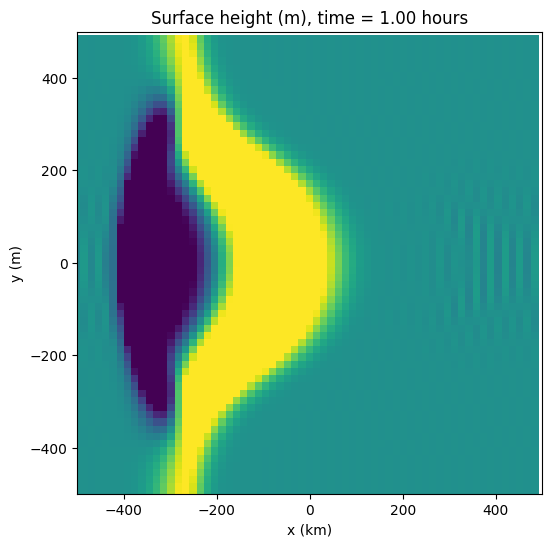

In [25]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 0.001* kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 1 * kilometer # minimum depth above the seamount
w1 = 50 * kilometer # Set the width of the wave
w2 = 200 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 60 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing


# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

I'm honestly not too sure what I'm looking it at here. But we know that the assumptions for the shallow water equatiins have waveheight (h) << fluid height (H) and because we've decreased the ocean depth we have violated that conditon and so the waves start to break.

## 3. Shallow water equations on a sphere

Of course the Earth isn't a flat plane. A great strength of Dedalus is its flexibility to solve equations in various geometries. The script below solves the 2D shallow water equations on a spherical shell, where the azimuth and colatitude are the independent variables. The colatitude is the complementary angle to the latitude such that the colatitude is $0^\circ$ at the North Pole, $90^\circ$ at the Equator, and $180^\circ$ at the South Pole. The spherical geometry also allows us to take into account the Earth's rotation in a realistic way. In this part of the project, we will assume that the bottom of the ocean is flat and that the resting height of the ocean is a constant $H$.  

We will use Dedalus to solve the following equations:
$$ \partial_t \mathbf{u} + g \nabla h + 2 \Omega \hat{\mathbf{z}} \times \mathbf{u} = -\mathbf{u} \cdot \nabla \mathbf{u} $$
$$ \partial_t + H \nabla \cdot \mathbf{u} = -\nabla \cdot (h \mathbf{u}) $$

where $\mathbf{u}$ is the velocity vector, $\Omega$ is the Earth's angular velocity (in radians per second), and $\hat{\mathbf{z}}$ is a unit vector aligned with the North Pole. Note that we have written the equations above in vector form. Dedalus includes vector calculus operators that make it very natural to solve equations like this without worrying about the particular form of the vector operators in a curvilinear coordinate system.

### 3.1  Dedalus script for 2D shallow water equations on a sphere

In [10]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128 # Number of gridpoints in phi (longitude)
Ntheta = 64 # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer
Omega = 2 * np.pi / (1 * day) # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2 # Gravitational acceleration
H = 4 * kilometer # Depth of the ocean
width = 2*np.pi*10/360 # Width of the initial Gaussian in radians
phi0 = np.pi # Longitude of the initial Gaussian height perturbation in radians
theta0 = np.pi/4 # Colatitude of the initial Gaussian height perturbation in radians

timestep = 600 * second
stop_sim_time = 10 * day

# Bases
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)

# Define the coordinates
phi, theta = dist.local_grids(basis) # Longitude and colatitude
lat = 360*(np.pi / 2 - theta)/(2*np.pi)  # latitude in degrees

# Fields
u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)

# Operators
# First, create an operator to perform the cross product: "z x ", where z is the local vertical unit vector
# The "skew" operator performs a 90 degree rotation of a vector field,
# so that skew([u,v]) = [-v, u].  MulCosine multiplies by the cosine of the latitude
zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))

# Set the initial conditions
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
h['g'] = np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
# Set the initial velocity to zero
u['g'][0] = 0 # the x-component of the velocity
u['g'][1] = 0 # the y-component of the velocity

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")
problem.add_equation("dt(h) + H*div(u) = - div(h*u)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save = np.array(h_save)

INFO:subsystems:Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 2s, Rate: 3.3e+01/s


2025-11-25 23:12:05,049 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 2s, Rate: 3.3e+01/s


INFO:subsystems:Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 4.6e+01/s


2025-11-25 23:12:05,170 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 4.6e+01/s


INFO:subsystems:Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 1s, Rate: 4.8e+01/s


...

2025-11-25 23:13:23,910 solvers 0/1 INFO :: Run time (iter 10-end): 72.61 sec


INFO:solvers:CPU time (iter 10-end): 0.02017 cpu-hr


2025-11-25 23:13:23,911 solvers 0/1 INFO :: CPU time (iter 10-end): 0.02017 cpu-hr


INFO:solvers:Speed: 4.762e+05 mode-stages/cpu-sec


2025-11-25 23:13:23,912 solvers 0/1 INFO :: Speed: 4.762e+05 mode-stages/cpu-sec


### 3.2  Plotting
The code below will make a movie of the height as a function of x and y

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-25 23:13:24,089 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp5j7o379j/temp.m4v


2025-11-25 23:13:24,090 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmp5j7o379j/temp.m4v


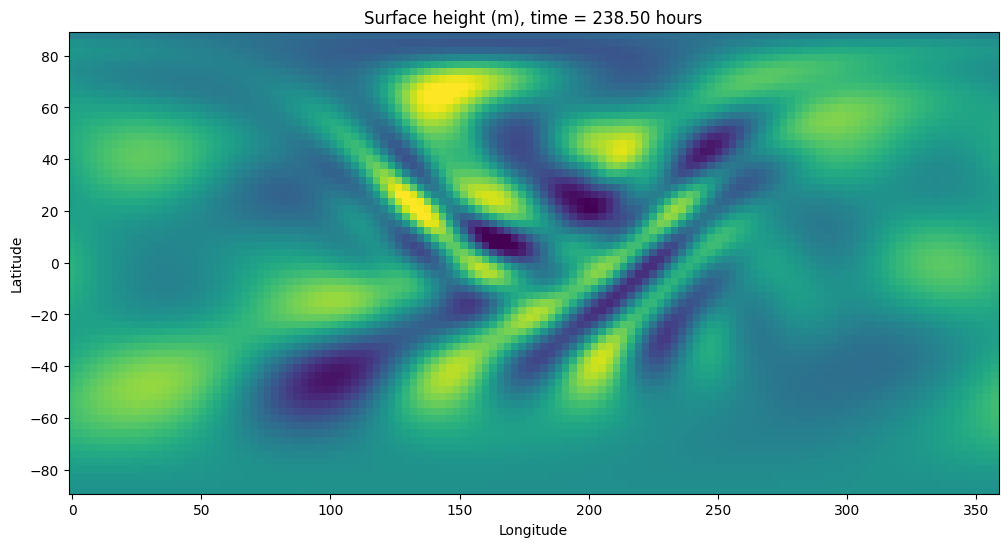

In [11]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(np.pi/2 - theta)*360/2/np.pi, np.squeeze(phi)*360/2/np.pi)

# Define an animation function
def drawframe(n):
    plt.clf()
    height = plt.pcolor(Y, X, h_save[n,:,:], vmin=-0.1, vmax=0.1)
    # Specify the axis limits and labels
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

### 3.3 Student investigation
<a id='section3pt3'></a>
Create a virtual tide gauge by sampling the height at a point at a latitude of 45ºN and longitude of 90ºW and plot the timeseries of the height at this point in the cells below. You should modifty the code to save the height more often so that you can clearly see the shape of the wave. Notice that as the waves propagate around the Earth, their shape changes. Discuss physical mechanisms that might cause the shape of the wave to change as the wave propagates.

INFO:subsystems:Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.8e+01/s


2025-11-25 23:14:08,726 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.8e+01/s


INFO:subsystems:Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 7.4e+01/s


2025-11-25 23:14:08,804 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 7.4e+01/s


INFO:subsystems:Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 1s, Rate: 6.9e+01/s


...

2025-11-25 23:16:49,625 solvers 0/1 INFO :: Run time (iter 10-end): 156.1 sec


INFO:solvers:CPU time (iter 10-end): 0.04335 cpu-hr


2025-11-25 23:16:49,628 solvers 0/1 INFO :: CPU time (iter 10-end): 0.04335 cpu-hr


INFO:solvers:Speed: 4.447e+05 mode-stages/cpu-sec


2025-11-25 23:16:49,632 solvers 0/1 INFO :: Speed: 4.447e+05 mode-stages/cpu-sec


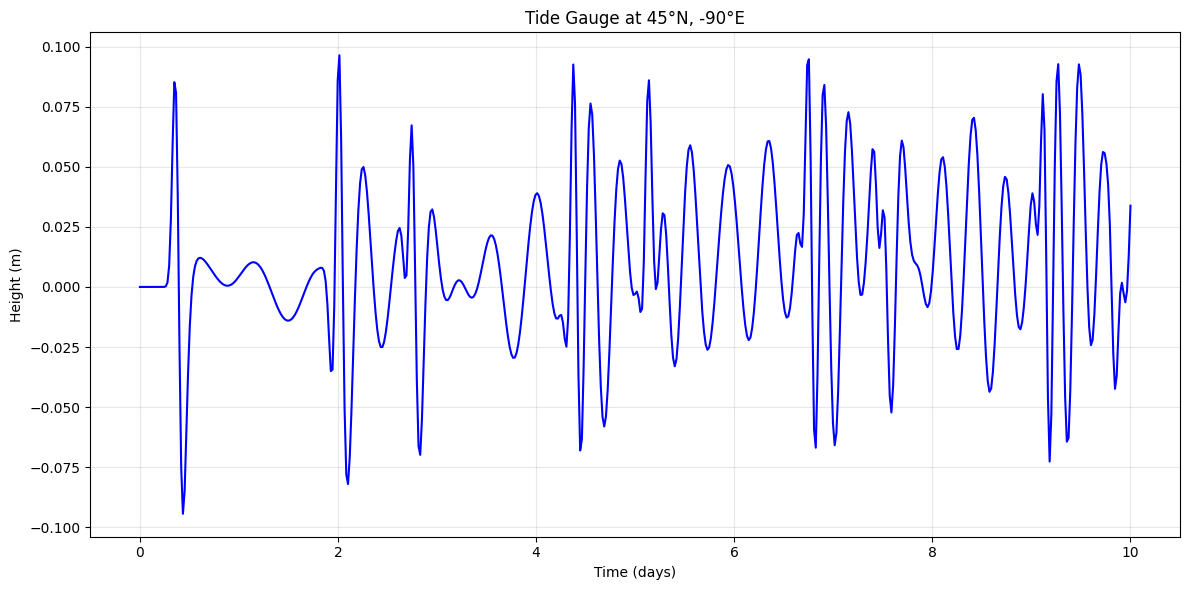

In [12]:

import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt


logger = logging.getLogger(__name__)


meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128  # Number of gridpoints in phi (longitude) - higher resolution for better wave representation
Ntheta = 64  # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer  # Earth's radius in meters
Omega = 2 * np.pi / (1 * day)  # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2  # Gravitational acceleration
H = 4 * kilometer  # Depth of the ocean
width = 2*np.pi*10/360  # Width of the initial Gaussian in radians (10 degrees converted to radians)
phi0 = np.pi
theta0 = np.pi/4

#reduced the time-step for more frequennt iterations
timestep = 300 * second
stop_sim_time = 10 * day

# Create coordinate system for spherical geometry (I find it so cool that it can do this)
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)  # Spectral basis functions


phi, theta = dist.local_grids(basis)
lat = 360*(np.pi / 2 - theta)/(2*np.pi)


u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)


zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))


#Our initial conditions
h.change_scales(1)
u.change_scales(1)


h['g'] = np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)  # Gaussian centered at (phi0, theta0)


u['g'][0] = 0  # Set longitudinal (east-west) component to zero
u['g'][1] = 0  # Set latitudinal (north-south) component to zero

# Define the tide gauge location (45°N, 90°W)
tide_gauge_lat = 45  # Latitude in degrees
tide_gauge_lon = -90  # Longitude in degrees

# Convert tide gauge location to computational coordinates
tide_gauge_theta = np.pi/2 - np.radians(tide_gauge_lat)  # Convert latitude to colatitude
tide_gauge_phi = np.radians(tide_gauge_lon) % (2*np.pi)  # Convert longitude to radians, ensure 0-2π range

# Find the grid point closest to the tide gauge location
# Calculate distance from each grid point to tide gauge location
distance = np.sqrt((phi - tide_gauge_phi)**2 + (theta - tide_gauge_theta)**2)
# Find index of minimum distance - this is our tide gauge point
tide_gauge_idx = np.unravel_index(np.argmin(distance), distance.shape)


tide_gauge_phi_idx, tide_gauge_theta_idx = tide_gauge_idx

# Define the initial value problem (IVP)
problem = dedalus.IVP([u, h], namespace=locals())  # Create IVP with our variables


#actually solving the equations
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")  # Nonlinear shallow water equations


problem.add_equation("dt(h) + H*div(u) = - div(h*u)")  # Nonlinear shallow water equations

# Build the solver using 2nd-order Runge-Kutta method
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time  # Set simulation end time

h.change_scales(1)  # Ensure we're on physical grid for data collection

# Store initial conditions
h_save = [np.copy(h['g'])]  # Store full height field snapshot
t_save = [solver.sim_time]  # Store corresponding time


tide_gauge_data = []  # Will store height at tide gauge location
tide_gauge_times = []  # Will store corresponding times

# Record initial tide gauge measurement
h.change_scales(1)  # Switch to physical grid for data collection
current_h = h['g']  # Get current height field
tide_gauge_height = current_h[tide_gauge_phi_idx, tide_gauge_theta_idx]  # Extract height at tide gauge location
tide_gauge_data.append(tide_gauge_height)  # Store initial height
tide_gauge_times.append(solver.sim_time)  # Store initial time

# Main simulation loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)  # Advance simulation by one timestep

        # Collect data every timestep (instead of every 10 steps) for higher temporal resolution
        if solver.iteration % 5 == 0:  # Changed from every 10 iterations to every iteration
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))

            # Save full field snapshot less frequently to save memory
            if solver.iteration % 20 == 0:  # Save full field every 20 iterations
                h.change_scales(1)
                h_save.append(np.copy(h['g']))
                t_save.append(solver.sim_time)

            # Always save tide gauge data at high frequency
            h.change_scales(1)  # Switch to physical grid
            current_h = h['g']  # Get current height field
            tide_gauge_height = current_h[tide_gauge_phi_idx, tide_gauge_theta_idx]  # Sample at tide gauge
            tide_gauge_data.append(tide_gauge_height)  # Store time series data
            tide_gauge_times.append(solver.sim_time)  # Store corresponding time

except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()  # Print solver statistics

# Convert lists to numpy arrays for easier analysis
h_save = np.array(h_save)
tide_gauge_data = np.array(tide_gauge_data)
tide_gauge_times = np.array(tide_gauge_times)

# Plot the tide gauge time series
plt.figure(figsize=(12, 6))
plt.plot(tide_gauge_times/day, tide_gauge_data, 'b-', linewidth=1.5)  # Convert time to days for x-axis
plt.xlabel('Time (days)')
plt.ylabel('Height (m)')
plt.title(f'Tide Gauge at {tide_gauge_lat}°N, {tide_gauge_lon}°E')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

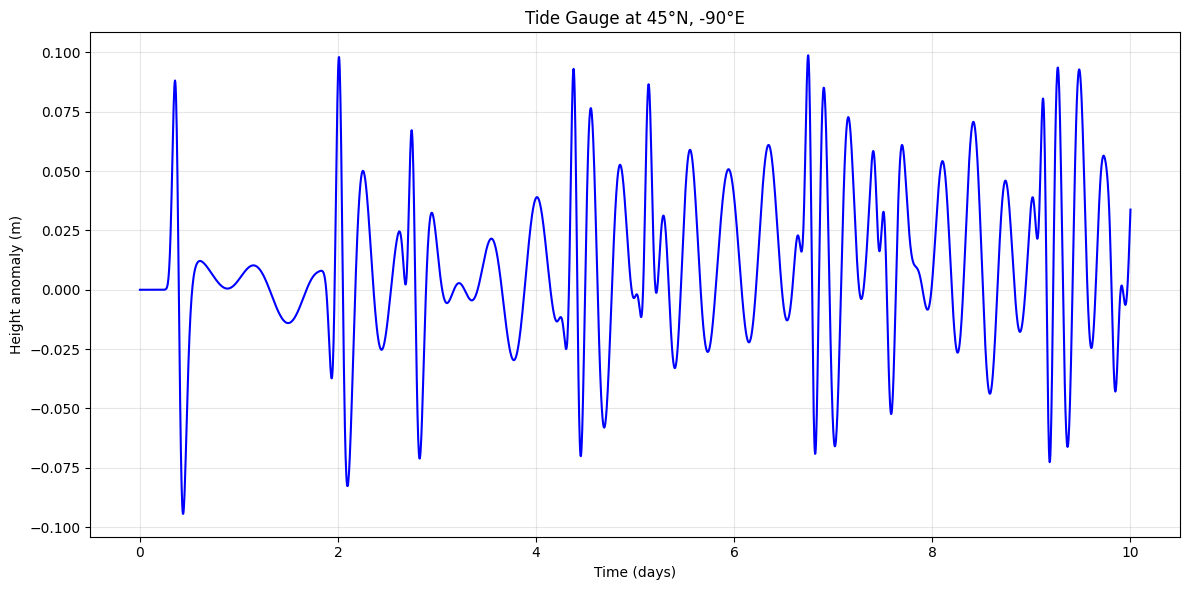


Here's what the height looks like at this spefcic point on the globe

In the simulation above, the Tsunami wave travels around the planet many times. In reality, the waves will partially dissipate when they reach shorelines. In the spherical shallow water equation code above (or in a new code block below), add a forcing term to the shallow water equations that damps the waves for longitudes larger than $\pm 90^\circ$. Specifically, add a forcing function to the right hand side of the height equation of the following form:

$$ - (1/\tau) f(\phi) h$$

where

$$ f(\phi) = \frac{1}{2}\left(1+tanh\left(\frac{\phi-3\pi/2}{\pi/10}\right)\right) + \frac{1}{2}\left(1-tanh\left(\frac{\phi-\pi/2}{\pi/10}\right)\right) $$

and $\phi$ is the longitude in radians and $\tau$ is a damping timescale. A timescale of $\tau=0.1$ days should be sufficient to damp the waves.

With this damping term active, much more slowly propagating waves should be visible. These are shallow water Rossby waves. Estimate the east/west phase speed of these Rossby waves from the theoretical dispersion relation and compare this estimate with the phase speed that you can infer from the simulation by plotting the height, $h$, as a function of longitude and time. Discuss the spatial structure of the Rossby waves and any discrepancies that you see between your estimated and measured phase speeds.

In [13]:
np.tanh(1)

np.float64(0.7615941559557649)

In [54]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128 # Number of gridpoints in phi (longitude)
Ntheta = 64 # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer
Omega = 2 * np.pi / (1 * day) # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2 # Gravitational acceleration
H = 4 * kilometer # Depth of the ocean
width = 2*np.pi*10/360 # Width of the initial Gaussian in radians
phi0 = np.pi # Longitude of the initial Gaussian height perturbation in radians
theta0 = np.pi/4 # Colatitude of the initial Gaussian height perturbation in radians

#include our tau term
tau = 1000


timestep = 300 * second
stop_sim_time = 10 * day

# Bases
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)

# Define the coordinates
phi, theta = dist.local_grids(basis) # Longitude and colatitude
lat = 360*(np.pi / 2 - theta)/(2*np.pi)  # latitude in degrees

# Define f as a Dedalus Field
f_field = dist.Field(name='f', bases=basis)
f_field['g'] = 1/2*(1 + np.tanh((phi - 3*np.pi / 2)/ (np.pi/10))) + 1/2*(1 - np.tanh((phi - np.pi/2)/ (np.pi/10)))

# Fields
u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)

# Operators
# First, create an operator to perform the cross product: "z x ", where z is the local vertical unit vector
# The "skew" operator performs a 90 degree rotation of a vector field,
# so that skew([u,v]) = [-v, u].  MulCosine multiplies by the cosine of the latitude
zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))

# Set the initial conditions
h.change_scales(1) # Set values on regular grid
u.change_scales(1)


h['g'] =  np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)

# CRITICAL CHANGE: Start with much smaller velocity
u['g'][0] = 0
u['g'][1] = 0

problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")
problem.add_equation("dt(h) + H*div(u) = - div(h*u) -(1/tau)*f_field*h")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time

# Main loop - ADD STABILITY CHECK
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)

        # ADDED: Check for NaN values
        h.change_scales(1)
        if np.any(np.isnan(h['g'])):
            logger.error(f'NaN values detected at iteration {solver.iteration}! Stopping.')
            break

        if (solver.iteration-1) % 10 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save = np.array(h_save)


INFO:subsystems:Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.2e+01/s


2025-11-26 00:04:15,703 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 5.2e+01/s


INFO:subsystems:Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 6.5e+01/s


2025-11-26 00:04:15,790 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 1s, Rate: 6.5e+01/s


INFO:subsystems:Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 1s, Rate: 6.8e+01/s


...

2025-11-26 00:07:23,546 solvers 0/1 INFO :: Run time (iter 10-end): 180 sec


INFO:solvers:CPU time (iter 10-end): 0.05001 cpu-hr


2025-11-26 00:07:23,547 solvers 0/1 INFO :: CPU time (iter 10-end): 0.05001 cpu-hr


INFO:solvers:Speed: 3.855e+05 mode-stages/cpu-sec


2025-11-26 00:07:23,549 solvers 0/1 INFO :: Speed: 3.855e+05 mode-stages/cpu-sec


In [52]:
h_save

array([[[ 4.20241707e-218,  6.07834010e-215,  7.86373498e-212, ...,
          1.74625578e-147,  2.02441141e-148,  2.03832083e-149],
        [ 9.69119672e-214,  1.40172640e-210,  1.81345643e-207, ...,
          4.02704159e-143,  4.66849646e-144,  4.70057298e-145],
        [ 1.90787063e-209,  2.75952776e-206,  3.57008568e-203, ...,
          7.92789022e-139,  9.19069909e-140,  9.25384696e-141],
        ...,
        [ 3.20637040e-205,  4.63766672e-202,  5.99989165e-199, ...,
          1.33236249e-134,  1.54459035e-135,  1.55520299e-136],
        [ 1.90787063e-209,  2.75952776e-206,  3.57008568e-203, ...,
          7.92789022e-139,  9.19069909e-140,  9.25384696e-141],
        [ 9.69119672e-214,  1.40172640e-210,  1.81345643e-207, ...,
          4.02704159e-143,  4.66849646e-144,  4.70057298e-145]],

       [[ 1.15475550e-006, -8.87801723e-007,  6.33856561e-007, ...,
         -3.52957832e-006,  3.38456846e-006, -3.09135611e-006],
        [ 1.14769552e-006, -8.69447615e-007,  6.01802054e-007

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


2025-11-26 00:09:51,126 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>


INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpr02unr2h/temp.m4v


2025-11-26 00:09:51,128 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpr02unr2h/temp.m4v


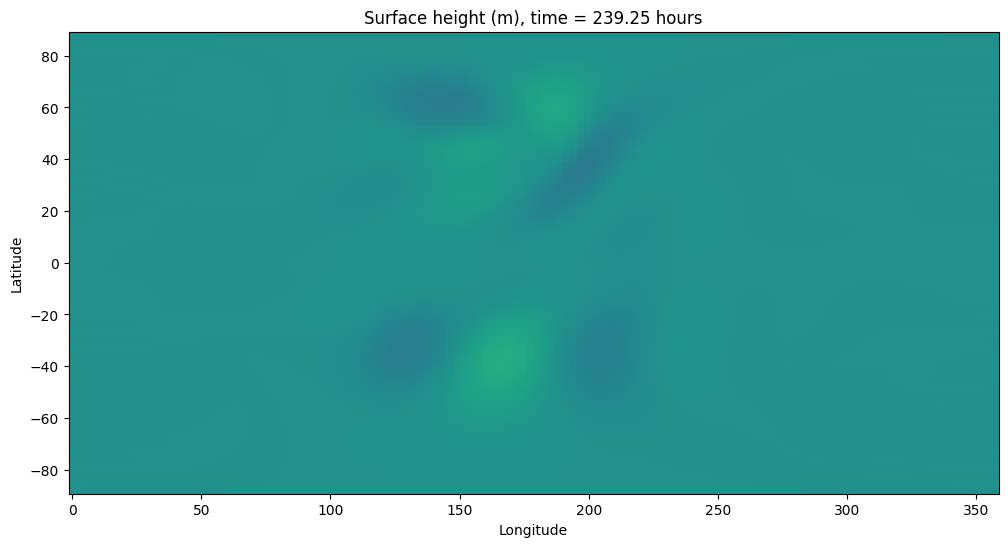

In [55]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(np.pi/2 - theta)*360/2/np.pi, np.squeeze(phi)*360/2/np.pi)

# Define an animation function
def drawframe(n):
    plt.clf()
    height = plt.pcolor(Y, X, h_save[n,:,:], vmin=-0.1, vmax=0.1)
    # Specify the axis limits and labels
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

Getting the Theoretical values

In [60]:
# Calculate theoretical Rossby wave parameters
a = R  # Earth's radius

# Key parameters at your perturbation location (45°N)
f0 = 2 * Omega * np.sin(theta0)  # Coriolis at 45°N
beta = 2 * Omega * np.cos(theta0) / a  # β at 45°N
Rd = np.sqrt(g * H) / f0  # Rossby radius

print(f"f₀ at 45°N: {f0:.2e} s⁻¹")
print(f"β at 45°N: {beta:.2e} m⁻¹s⁻¹")
print(f"Rossby radius R_d: {Rd/1e3:.1f} km")

# Estimate dominant wavenumber from your Gaussian width
k_dominant = 1 / (width * a)  # Based on initial condition width
print(f"\nDominant wavenumber estimate: {k_dominant:.2e} m⁻¹")
print(f"Wavelength: {2*np.pi/k_dominant/1e3:.0f} km")

# Theoretical Rossby wave phase speed
def rossby_phase_speed(k, l=0):
    """Rossby wave phase speed: c = -β / (k² + l² + Rd⁻²)"""
    return -beta*k / (k**2 + l**2 + 1/Rd**2)

c_phase_theoretical = rossby_phase_speed(k_dominant)
print(f"\nTheoretical phase speed: {c_phase_theoretical:.5f} m/s")
print(f"Theoretical phase speed: {c_phase_theoretical * 86400 / 1e3:.2f} km/day")
print(f"Direction: {'WESTWARD' if c_phase_theoretical < 0 else 'EASTWARD'}")

f₀ at 45°N: 1.03e-04 s⁻¹
β at 45°N: 1.61e-11 m⁻¹s⁻¹
Rossby radius R_d: 1925.7 km

Dominant wavenumber estimate: 8.99e-07 m⁻¹
Wavelength: 6987 km

Theoretical phase speed: -0.00001 m/s
Theoretical phase speed: -0.00 km/day
Direction: WESTWARD


Plotting height vs longitude and time

TypeError: Length of x (1) must match number of columns in z (128)

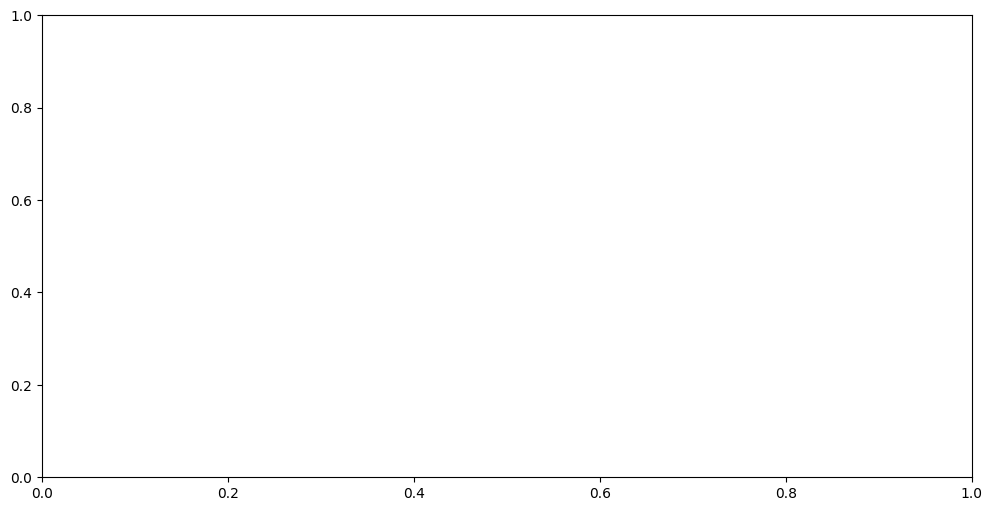

In [68]:
# Plot: Height vs Time with 6 different longitudes
plt.figure(figsize=(12, 6))

# Select 6 equally spaced longitudes
longitude_indices = np.linspace(0, len(longitude_deg)-1, 6, dtype=int)

for i, lon_idx in enumerate(longitude_indices):
    plt.plot(time_days, h_longitude_time[:, lon_idx],
             linewidth=2, label=f'Lon = {float(longitude_deg[lon_idx]):.0f}°')

plt.xlabel('Time (days)')
plt.ylabel('Height (m)')
plt.title('Height vs Time at Different Longitudes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Optional further investigations

* In the example of the shallow water equations on a sphere, introduce bathymetry by making $H$ a function of latitude and longitude. Make sure that you modify the equations in Dedalus appropriately. How do the waves behave when they encounter shallow water (e.g. a localized seamount)?

* It is quite difficult to simulate changing sea level (sometimes called wetting and drying), which is why the examples above do not include land. However, we can estimate the distance that a Tsunami will propagate using physical and dimensional arguments. Consider, for example, a flat, sloping beach. In the absence of energy dissipation, estimate the distance that a wave will propagate onshore. How could you modify this estimate to include energy dissipation (or drag)?